In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

In [69]:
## Desciptors listed out in MolCLR that are releant imho.
c = pd.read_csv('selected_props_for_mahalanobis.csv')
prop_names = c['prop_name'].values.tolist()

In [2]:
import pandas as pd
from contra_seq_dataset import get_dataset_array, get_anc_map

## Load in training set.
home = '/home/kat/Repos/SALSA/'
anc_path = f'{home}data/model_ready/01/train/anchor_smiles.csv'
aug_path = f'{home}data/model_ready/01/train/augmented_smiles.csv'
df_data = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(df_data)

## Load in distances.
df = pd.read_csv('20220530_paired_dists.csv')
display(df)

,anc_idx,aug_idx,distance
0,0,20000,2.395368
1,0,20001,2.186118
2,0,20002,2.796205
3,0,20003,2.290414
4,0,20004,4.379040
...,...,...,...
99995,19999,119995,2.192326
99996,19999,119996,4.533134
99997,19999,119997,1.990778
99998,19999,119998,3.336387


In [3]:
df_dists = df[['distance']]
display(df_dists.describe())

,distance
count,100000.000000
mean,3.628234
std,3.898840
min,0.000000
25%,2.278820
50%,2.857505
75%,4.012696
max,126.655586


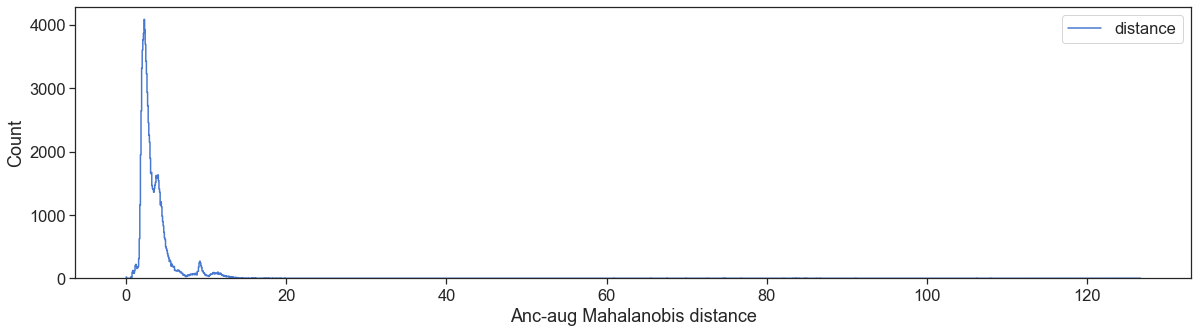

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='ticks',font_scale=1.5,palette='muted')

plt.figure(figsize=(20,5))
sns.histplot(df_dists, fill=False, element="step", kde=False) #, bw_adjust=.25)
plt.xlabel('Anc-aug Mahalanobis distance')
plt.show()

### Look at number of pairs in each quantile.

In [5]:
qs = [0.9, 0.95, 0.99, 0.995, 0.9975]

df_quants = df_dists.quantile(qs)
df_quants.columns = ['cutoff']
df_quants['count'] = df_quants.cutoff.apply(lambda x: df_dists[df_dists >= x].count())
display(df_quants)

,cutoff,count
0.9000,5.285735,10000
0.9500,8.664231,5000
0.9900,11.937563,1000
0.9950,13.037276,500
0.9975,15.583480,250


In [52]:
# # # # # # # # # # #
thresh = 10=
# # # # # # # # # # #

far_anc_to_augs = {}

for tup in df.itertuples():
    anc = tup.anc_idx
    aug = tup.aug_idx
    if tup.distance >= thresh:
        far_anc_to_augs.setdefault(anc, []).append(aug)
print(len(far_anc_to_augs))

2501


In [53]:
far_ancs = far_anc_to_augs.keys()
df_far_ancs = pd.DataFrame(far_ancs,columns=['idx'])
df_far_ancs['smiles'] = df_far_ancs.apply(lambda x: df_data.smiles.values[x])
df_far_ancs['len'] = df_far_ancs.smiles.apply(lambda x: len(x))
df_far_ancs = df_far_ancs.sort_values(by='len', ascending=True, ignore_index=True)
df_far_ancs

,idx,smiles,len
0,17529,CSCCCCCN=C=S,12
1,6951,OCCCCCNC(=S)S,13
2,6468,CCCC(CCC)C(=O)O,15
3,11924,NC(=O)NCc1cccs1,15
4,4070,Cc1nccn1CC(=O)O,15
...,...,...,...
2496,2528,CC(Oc1cc(Cl)c(Cl)cc1Cl)C(=O)NN1C(=O)CSC1c1cccc...,62
2497,17489,CN(C)C(=O)C1CCN(c2nc(=O)c3cc(C(F)(F)F)cc([N+](...,62
2498,12377,CC(=CC(=O)Nc1nnc(-c2ccc([N+](=O)[O-])cc2)s1)Nc...,67
2499,10531,CC(=O)OCC1=C(C(=O)O)N2C(=O)C(NS(=O)(=O)c3ccc([...,67


In [54]:
anc_to_dists = {}
for tup in df.itertuples():
    anc_idx = tup.anc_idx
    aug_idx = tup.aug_idx
    d = tup.distance
    anc_to_dists.setdefault(anc_idx, []).append(d)

In [55]:
from rdkit.Chem import AllChem
from rdkit import Chem, Geometry
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

def sm_and_mol(sm):
    mol = Chem.MolFromSmiles(sm)
    sm = Chem.MolToSmiles(mol)
    display(sm,mol)

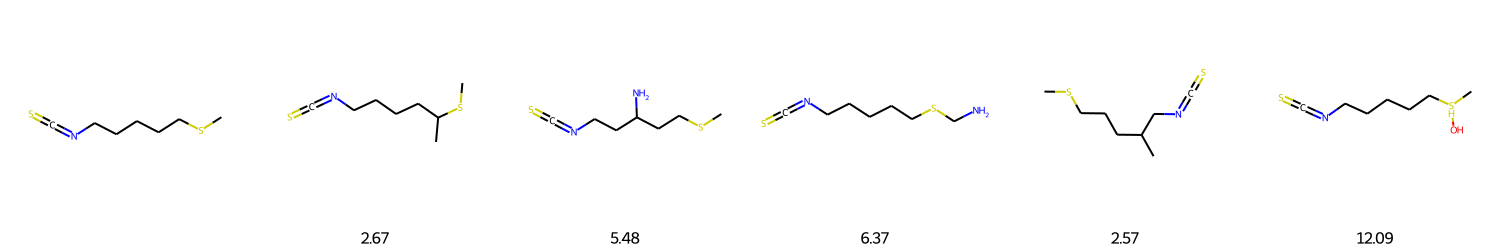

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



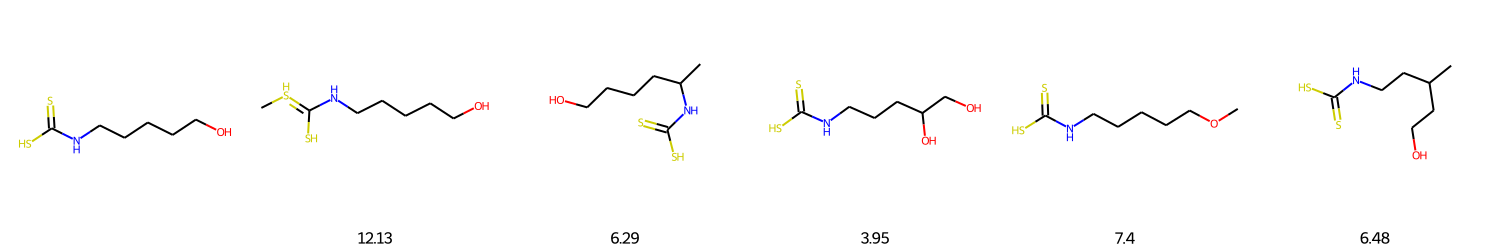

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



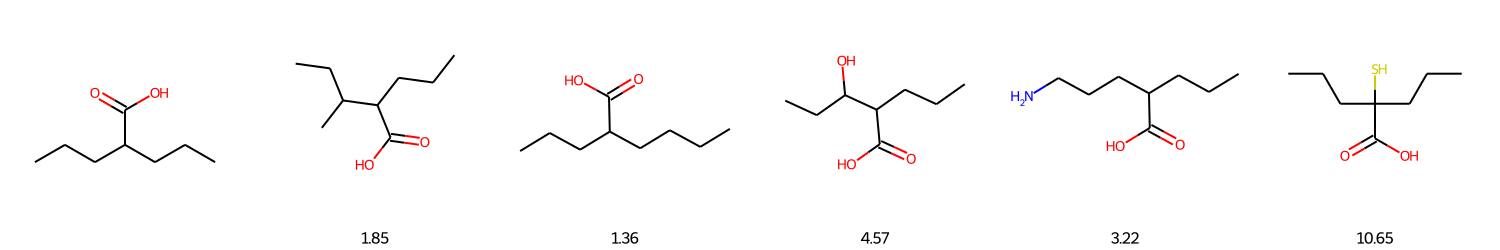

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



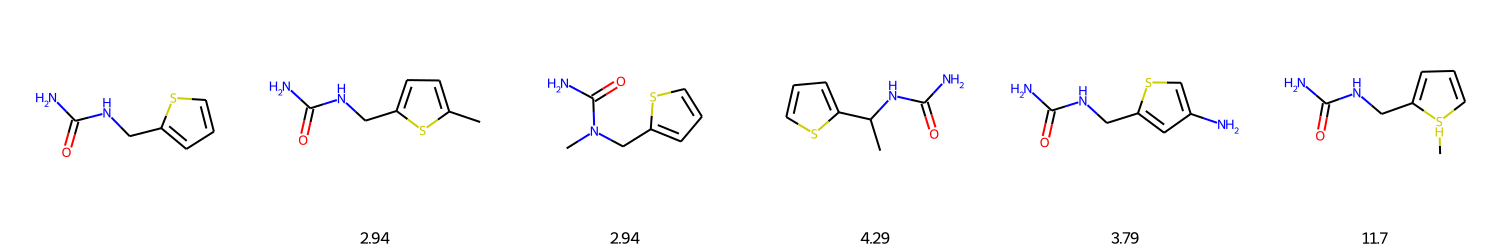

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



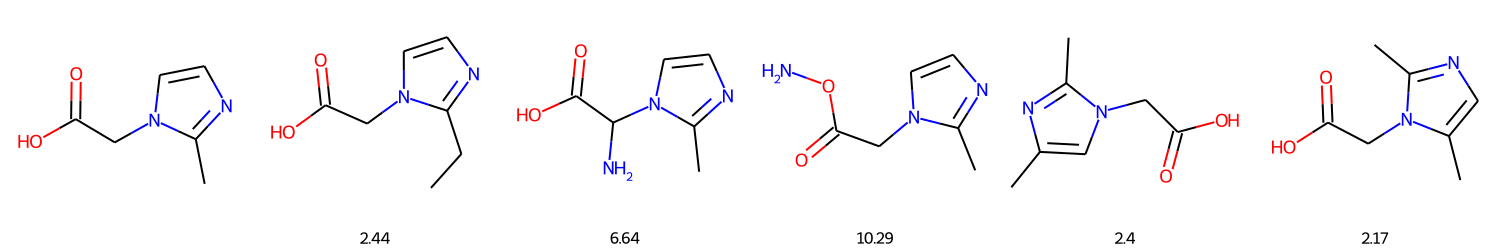

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



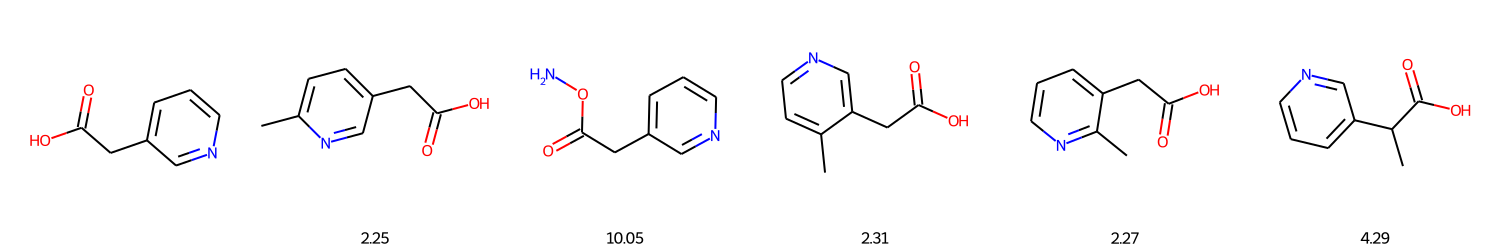

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



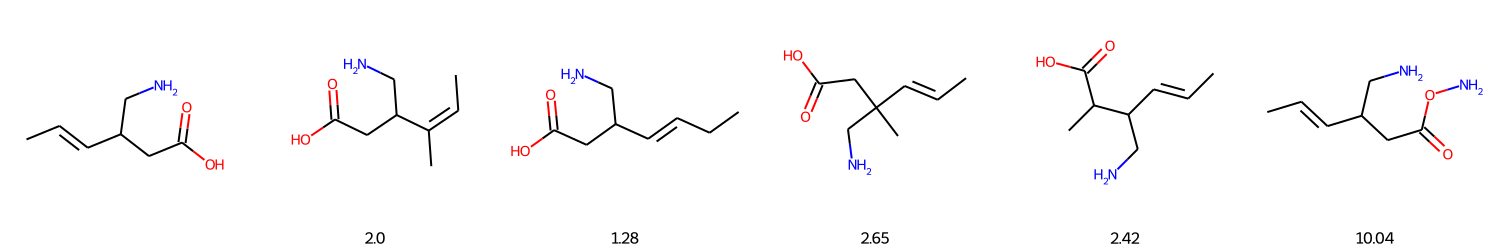

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



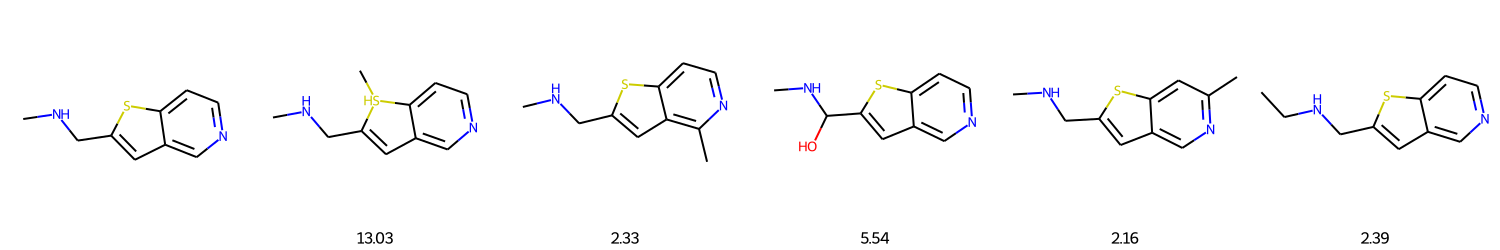

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



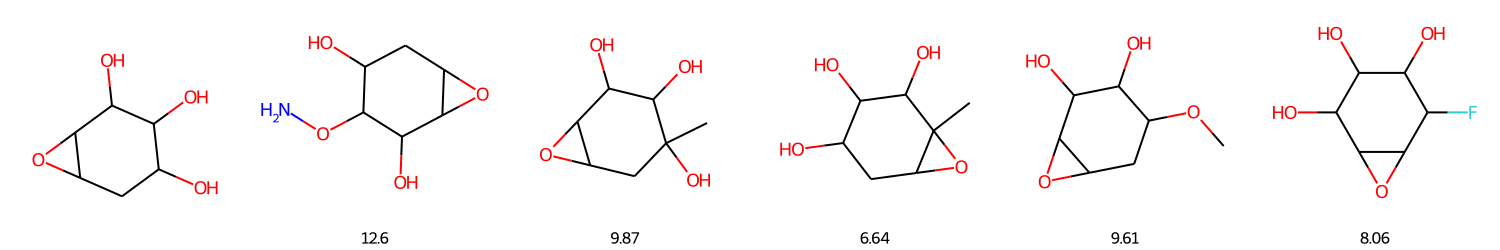

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



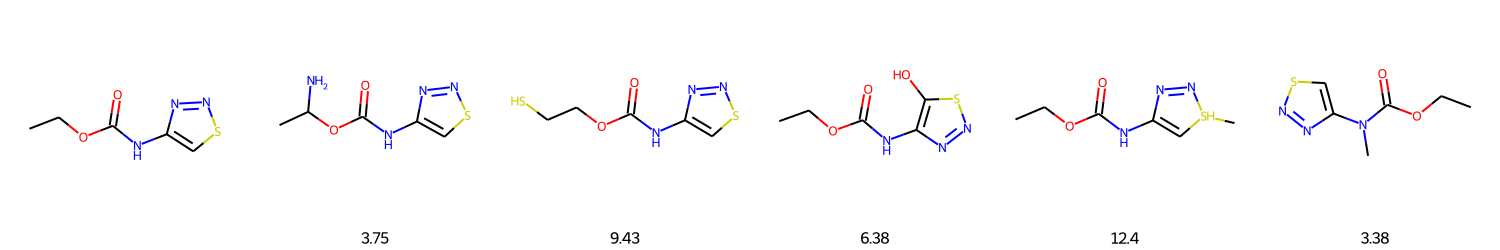

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



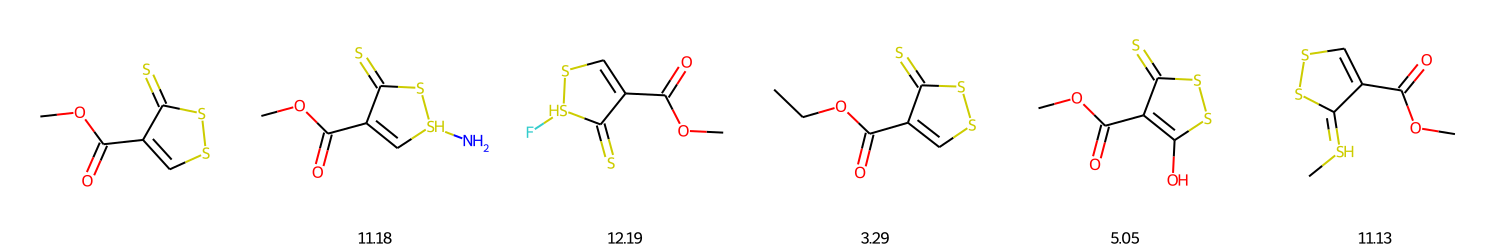

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



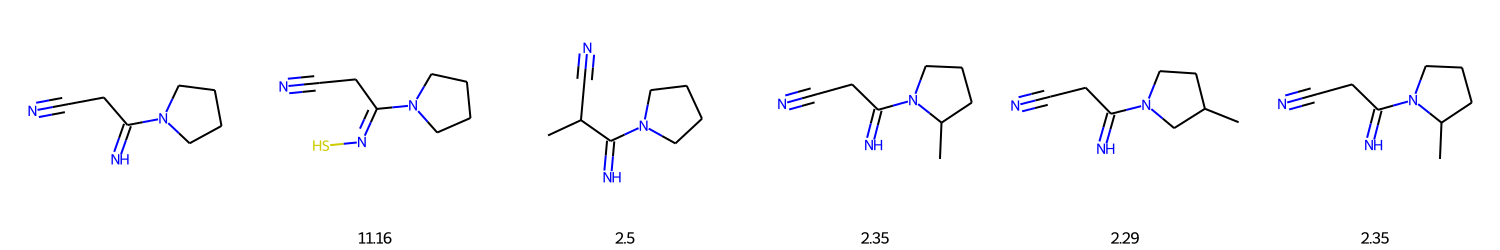

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



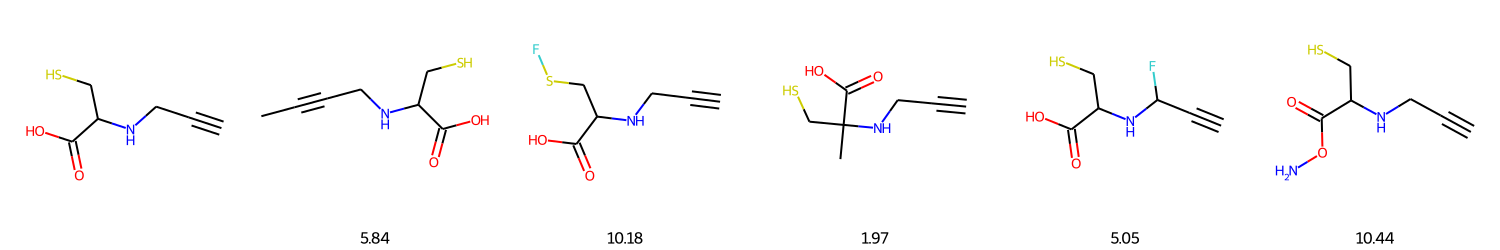

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



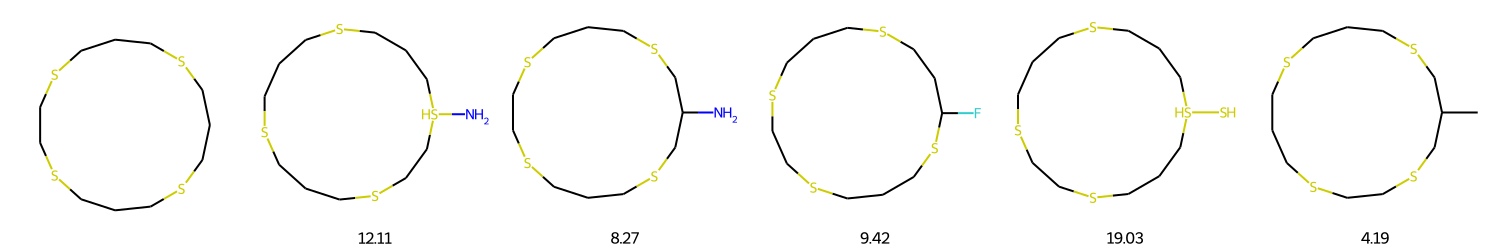

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



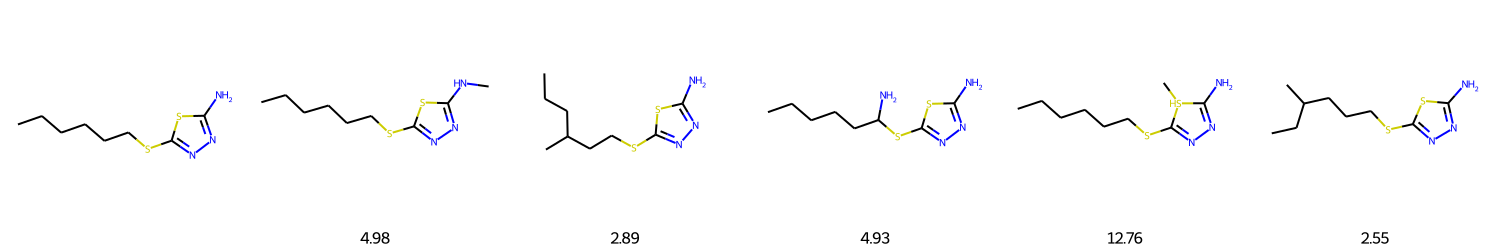

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



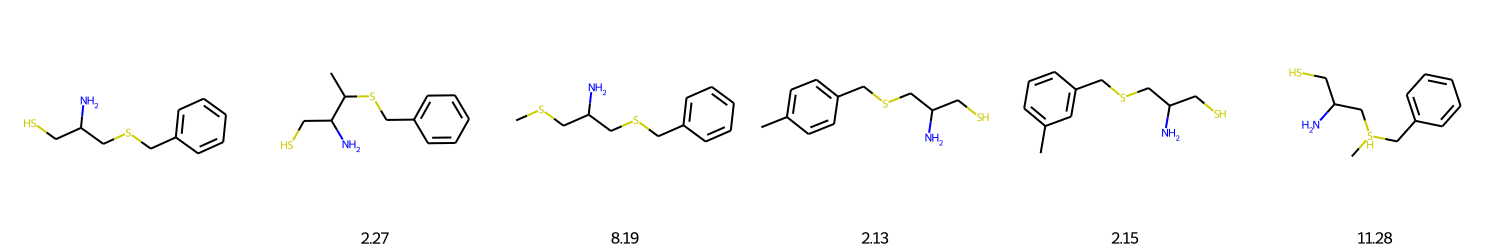

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



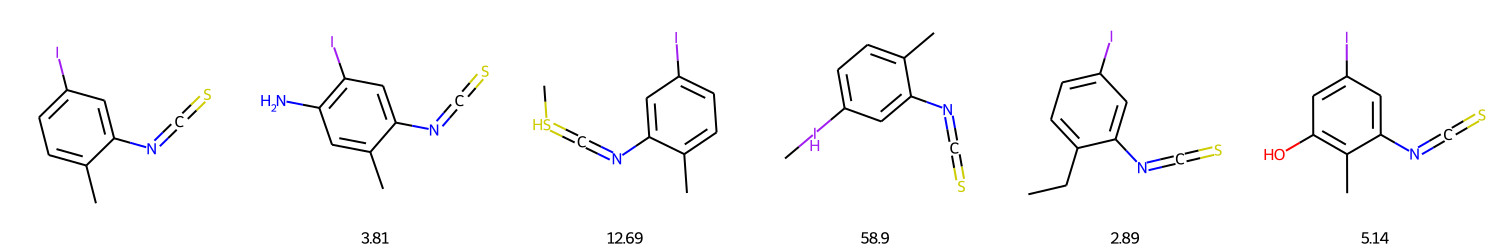

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



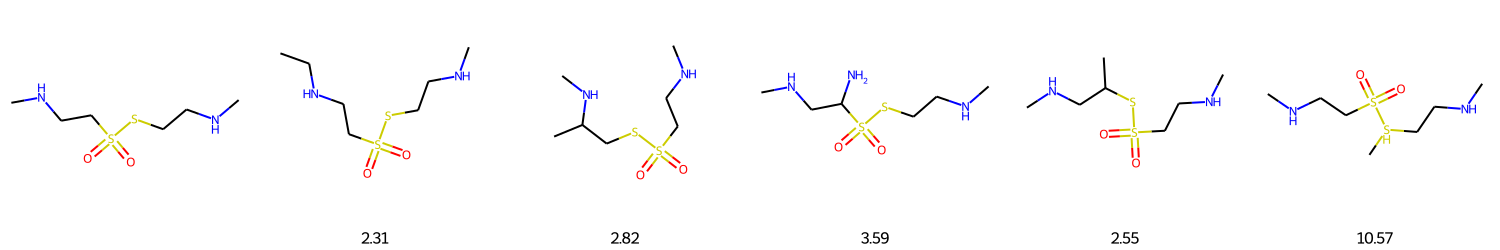

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



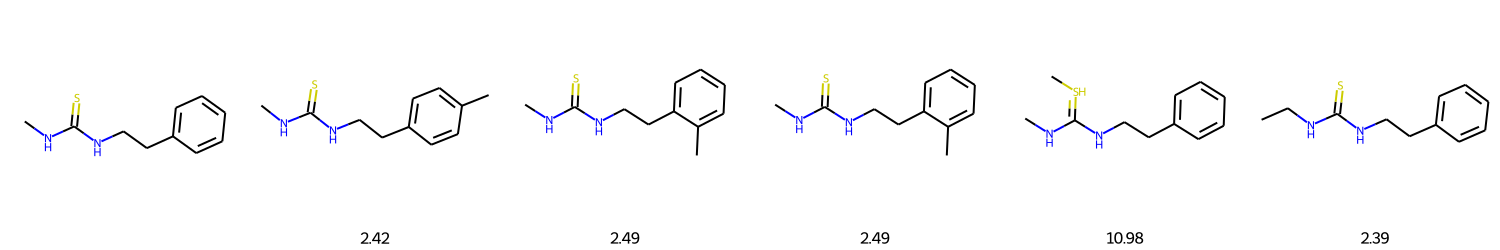

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



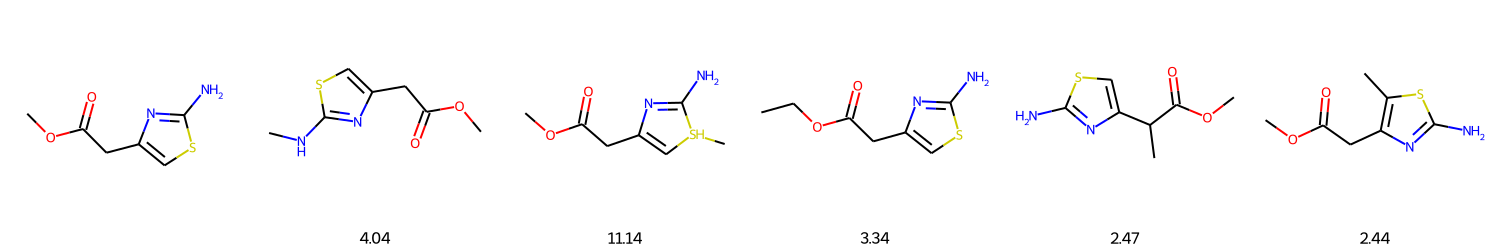

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



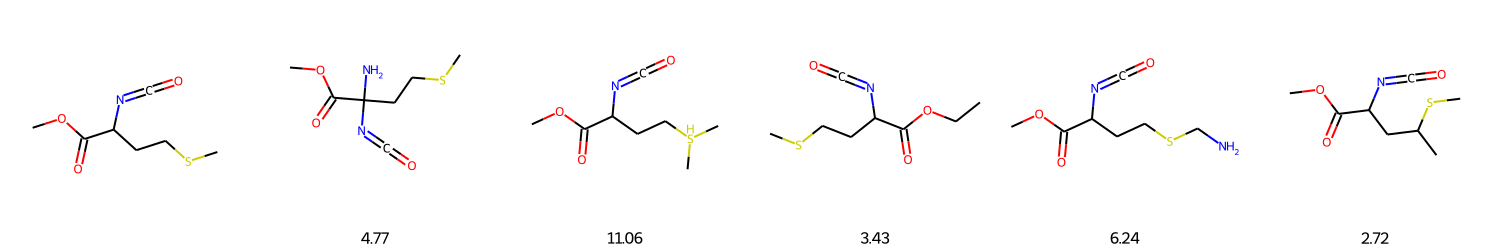

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



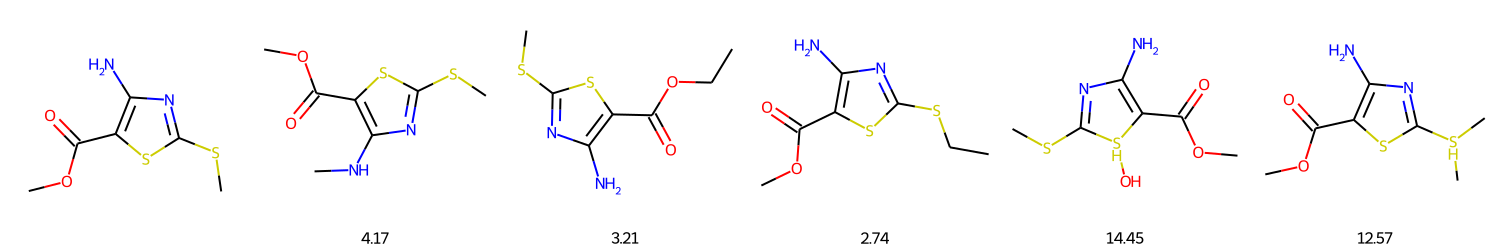

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



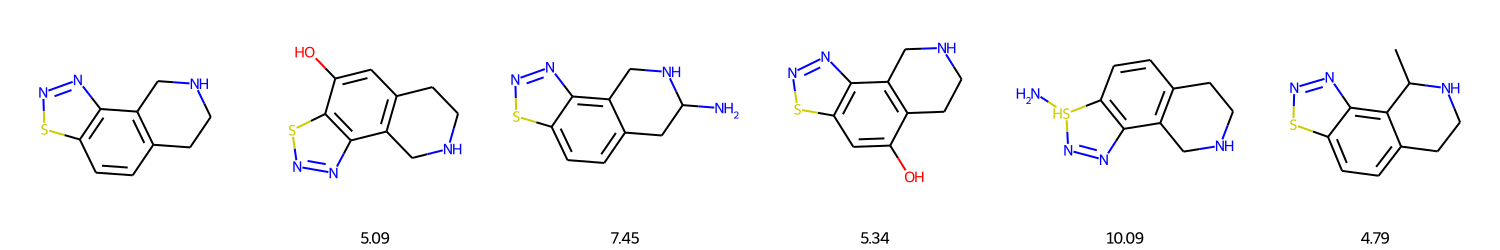

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



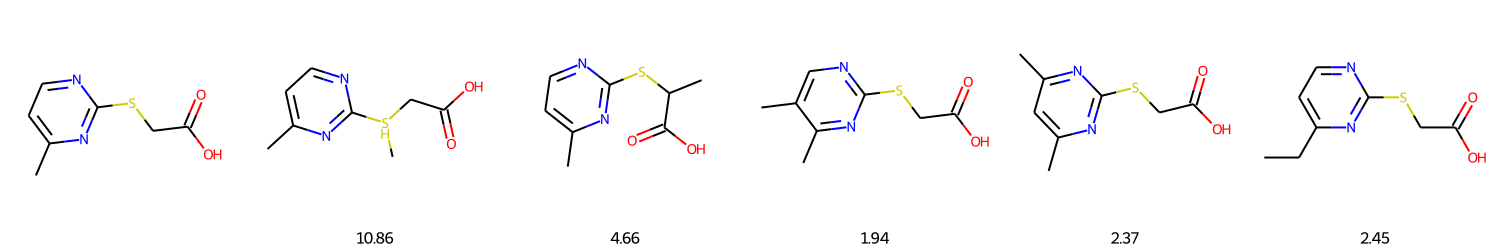

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



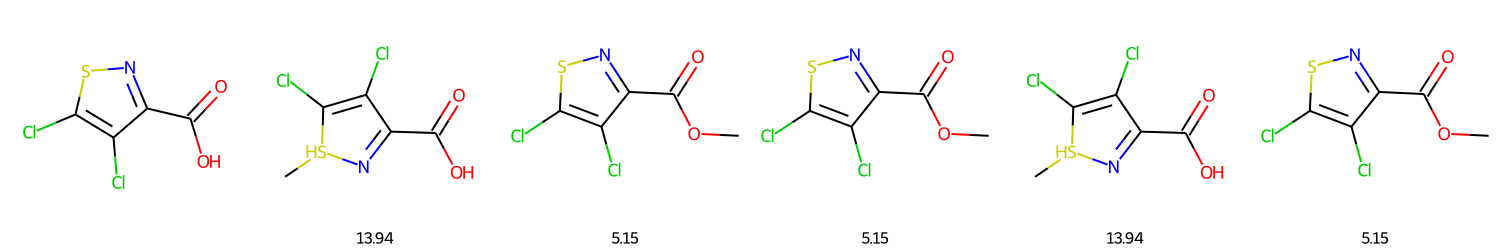

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



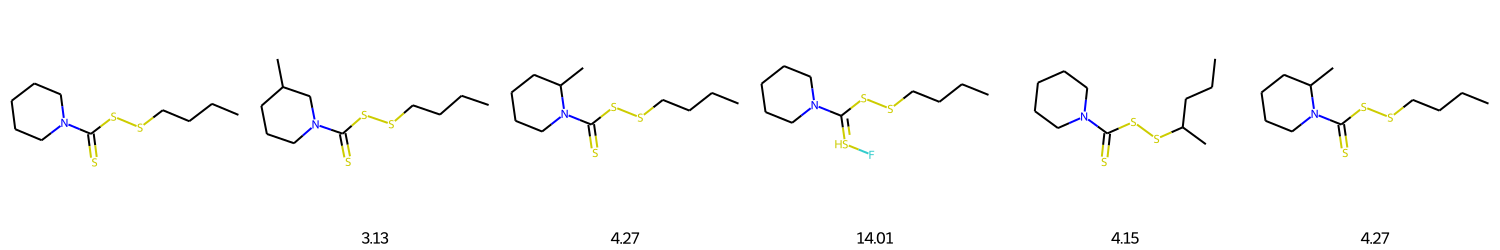

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



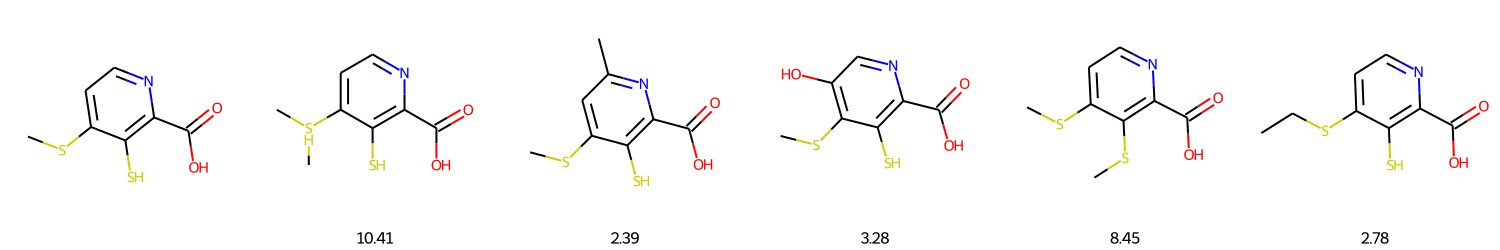

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



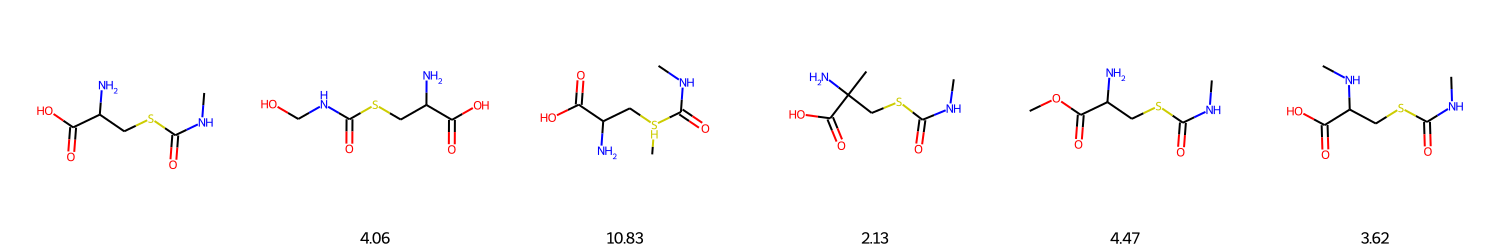

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



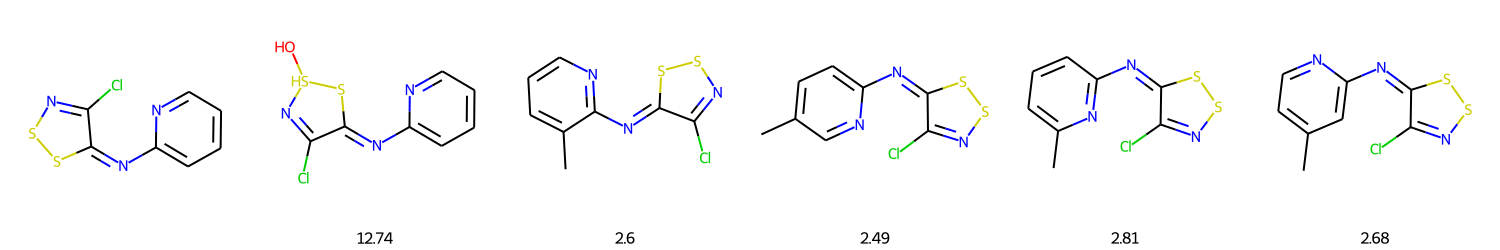

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



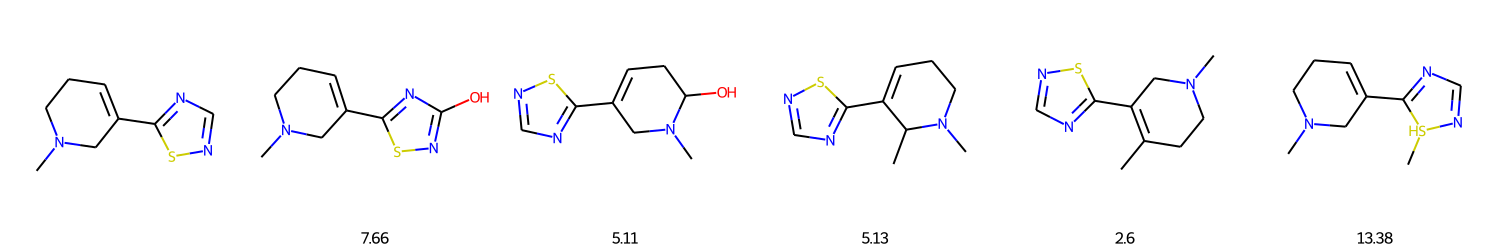

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



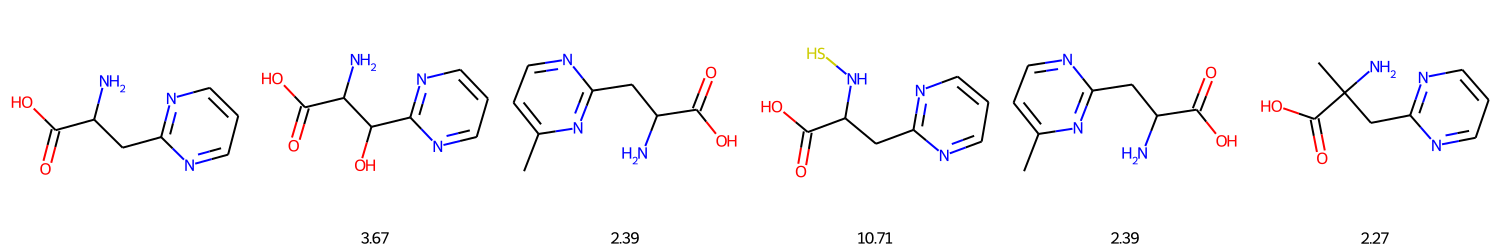

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



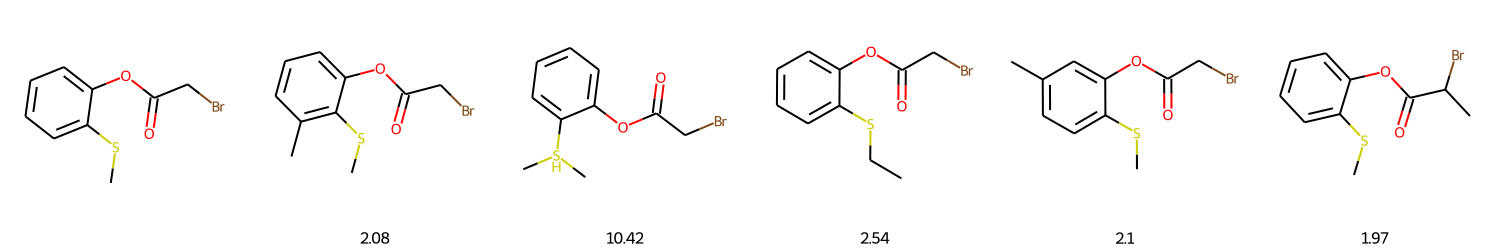

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



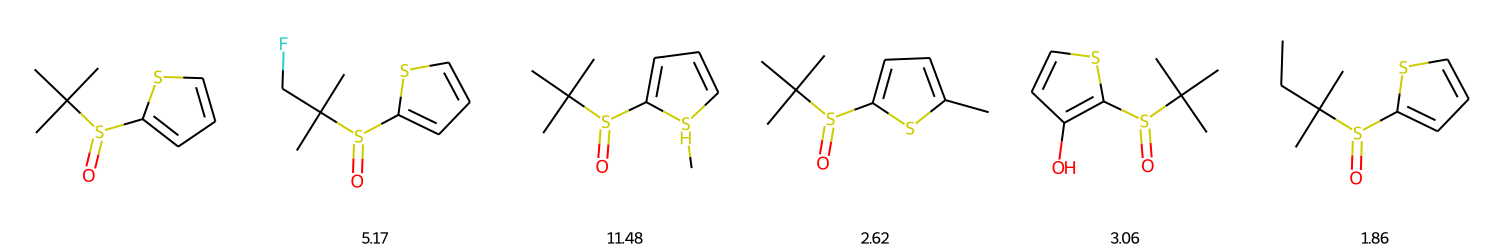

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  



In [67]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import PIL

smis = df_data.smiles.values

for i,row in df_far_ancs.iterrows():

    anc_idx = row.idx
    
    dists = [round(x, 2) for x in anc_to_dists[anc_idx]]
    dists = ['']+ [str(x) for x in dists]
   
    idc = anc_map[anc_idx].tolist()
    mols = [Chem.MolFromSmiles(smis[idx]) for idx in idc]
    
    img = Draw.MolsToGridImage(mols, molsPerRow=len(mols), subImgSize=(250, 250), legends=dists)

    display(img)

#     fig, ax = plt.subplots()
#     pix = np.array(img)
#     ax.imshow(poo)
#     rect = patches.Rectangle((50, 100), 40, 30, linewidth=1, edgecolor='r', facecolor='none')
    
    print("- "*50,"\n")
    
    if i==32:
        break